# Beschreibung #

"""

# PCA-Eigenwerte für Tennessee Eastman Process (TEP)

Dieses Notebook berechnet für jede Fehlerklasse (`faultNumber` 0-20) und jeden
Simulationslauf (`simulationRun`) die **PCA-Eigenwerte** des jeweiligen Runs
und fasst diese anschließend über die 500 Läufe pro Fehlerklasse mittels
Mittelwert und Standardabweichung zusammen.

**Datensatz**

Kaggle "tep-csv" (afrniomelo):
https://www.kaggle.com/datasets/afrniomelo/tep-csv

- `TEP_FaultFree_Training.csv`  (faultNumber = 0)
- `TEP_Faulty_Training.csv`     (faultNumber = 1..20)

Beide Dateien müssen im aktuellen Arbeitsverzeichnis liegen.

Eigenschaften des Datensatzes (laut Kaggle-Doku):
- Sampling-Intervall: alle 3 Minuten.
- Training: 500 Samples pro Run (= 25 h Simulationsdauer).
- Faulty Training: Fehler wird **1 Stunde nach Simulationsstart** injiziert
  → 60 min / 3 min = **20 Samples Vorlauf**, erstes Post-Fault-Sample ist
  `sample == 21`.

**Konzept**

- **Aktive Vorverarbeitung: `X_scaled = X - X.mean()`** (`global_mean`) — es
  wird ein **skalarer** Gesamtmittelwert über alle Variablen und Zeitpunkte
  abgezogen; die spaltenweisen Mittelwerte und die Roh-Varianzen bleiben
  erhalten. Die Hauptkomponenten werden dadurch von den varianzstärksten
  Rohvariablen dominiert — genau diese unskalierten Varianzverhältnisse
  tragen aber selbst Fehler-Information. Ein `StandardScaler` wird trotzdem
  auf Normalbetrieb (`faultNumber == 0`) aus `TEP_FaultFree_Training.csv`
  gefittet und steht als Alternative bereit (`X_scaled = scaler.transform(X)`,
  eine Zeile in `compute_eigenvalues_per_run`); die Ergebnisse dieser
  Variante liegen als `*_scaler.csv` archiviert.
- Pro Kombination (`faultNumber`, `simulationRun`) wird auf den
  vorverarbeiteten Run-Daten eine eigene **PCA gefittet** (alle Komponenten,
  `svd_solver="full"`). Übernommen wird `explained_variance_ratio_` — also
  der **Anteil** an der Gesamtvarianz je Hauptachse, nicht die Varianz
  selbst. Die Werte sind absteigend sortiert (`lambda_1` = größter Anteil)
  und summieren sich je Run auf 1; es sind die auf die Gesamtvarianz
  normierten Eigenwerte der empirischen Kovarianzmatrix. Das absolute
  Varianzniveau eines Runs geht dabei verloren — wer es behalten will,
  ersetzt im Code `explained_variance_ratio_` durch `explained_variance_`.
- Bei Fehlerklassen 1-20 werden die **Pre-Fault-Samples** (`sample < 21`)
  verworfen (Begründung siehe oben). Konsequenz: Fault 0 nutzt 500
  Beobachtungen pro Run, Fault 1-20 jeweils 480. Bei diesen Stichprobengrößen
  (>> 52 Variablen) ist der Einfluss auf die Kovarianzschätzung praktisch
  vernachlässigbar.
- Die letzten Eigenwerte (`lambda_51`, `lambda_52` ≈ 10⁻¹¹) liegen bei
  numerischem Null und bilden einen **Noise-Subspace** ab: zwischen den 52
  Prozessvariablen bestehen quasi-lineare Abhängigkeiten (z. B. durch
  Massen- und Stoffbilanzen im TEP). Sie werden in der Aggregat-Tabelle der
  Vollständigkeit halber mitgeführt; dargestellt werden nur die ersten
  Komponenten — `k_max = 25` in den Linienplots, `k_bar = 10` im Balkenplot.
- Über die 500 Läufe einer Fehlerklasse werden für jeden Eigenwertindex
  Mittelwert und Standardabweichung gebildet.

"""

# Imports #

In [1]:
# Standard-Imports
import numpy as np
import pandas as pd

# Scikit-Learn fuer Standardisierung und PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional: Fortschrittsbalken fuer lange Schleifen
try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

# Daten laden & Spalten prüfen #

In [2]:
# ============================================================
# Trainingsdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im aktuellen Arbeitsverzeichnis liegen.
#   - TEP_FaultFree_Training.csv : nur faultNumber == 0
#     -> 500 simulationRuns x 500 samples = 250 000 Zeilen
#   - TEP_Faulty_Training.csv    : faultNumber 1..20
#     -> 20 faults x 500 runs x 500 samples = 5 000 000 Zeilen

faultfree_train = pd.read_csv("TEP_FaultFree_Training.csv")
faulty_train    = pd.read_csv("TEP_Faulty_Training.csv")

print("FaultFree_Training shape:", faultfree_train.shape)
print("Faulty_Training shape   :", faulty_train.shape)

# ------------------------------------------------------------
# Metadaten-Spalten pruefen
# ------------------------------------------------------------
# Diese drei Spalten brauchen wir spaeter zum Gruppieren der Daten
# nach Fehlerklasse und Simulationslauf.
required_meta_cols = ["faultNumber", "simulationRun", "sample"]

for col in required_meta_cols:
    if col not in faultfree_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_FaultFree_Training.csv")
    if col not in faulty_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_Faulty_Training.csv")

# ------------------------------------------------------------
# Prozessvariablen automatisch erkennen
# ------------------------------------------------------------
# Der TEP-Datensatz enthaelt:
#   - xmeas_1 .. xmeas_41 : 41 gemessene Prozessgroessen
#   - xmv_1   .. xmv_11   : 11 Stellgroessen (manipulated variables)
# Zusammen 52 Prozessvariablen je Sample. Alles andere (faultNumber,
# simulationRun, sample) sind Metadaten und gehoeren NICHT in die PCA.
proc_cols = [
    c for c in faultfree_train.columns
    if c.startswith("xmeas_") or c.startswith("xmv_")
]

if not proc_cols:
    raise ValueError("Es wurden keine Prozessvariablen (xmeas_*/xmv_*) gefunden.")

print("Anzahl Prozessvariablen:", len(proc_cols))
print("Beispiel-Variablen:", proc_cols[:5])

FaultFree_Training shape: (250000, 55)
Faulty_Training shape   : (5000000, 55)
Anzahl Prozessvariablen: 52
Beispiel-Variablen: ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5']


# StandardScaler auf FaultFree_Training fitten (wird in der Schleife angewandt) #

In [3]:
# --- StandardScaler auf FaultFree_Training (Normalbetrieb) fitten ---
# Der Scaler wird hier GEFITTET, aktuell aber NICHT angewandt: aktiv ist
# X_scaled = X - X.mean() (global_mean) in compute_eigenvalues_per_run.
# Das Umschalten auf die spaltenweise Standardisierung
# scaler.transform(X) kostet nur diese eine Zeile (siehe Kommentar dort);
# bis dahin bleibt der Scaler ungenutzt.
#
# Hinweis: Eine zusaetzliche Sortierung der Rohdaten nach (simulationRun,
# sample) ist hier NICHT noetig - die Kovarianzberechnung pro Run ist
# permutationsinvariant, und die spaetere Schleife gruppiert ohnehin
# nach (faultNumber, simulationRun).

scaler = StandardScaler()

X_faultfree = faultfree_train[proc_cols].values
scaler.fit(X_faultfree)

print("StandardScaler auf FaultFree_Training angepasst.")
print("  Anzahl Prozessvariablen:", len(proc_cols))
print("  Mittelwerte (Auszug):    ", np.round(scaler.mean_[:5], 4))
print("  Std-Werte (Auszug):      ", np.round(scaler.scale_[:5], 4))

StandardScaler auf FaultFree_Training angepasst.
  Anzahl Prozessvariablen: 52
  Mittelwerte (Auszug):     [2.5050000e-01 3.6637857e+03 4.5088198e+03 9.3471000e+00 2.6902200e+01]
  Std-Werte (Auszug):       [3.09000e-02 3.40063e+01 3.92153e+01 8.57000e-02 2.11500e-01]


# Trainingsdaten zusammenführen (Fault 0-20) #

In [4]:
# ============================================================
# Trainingsdaten zusammenfuehren (Fault 0..20 in EINEM DataFrame)
# ============================================================
# Wir wollen anschliessend EINE Schleife ueber alle Kombinationen
# (faultNumber, simulationRun) laufen lassen. Dafuer fuegen wir
# FaultFree (= Fault 0) und Faulty (= Fault 1..20) zusammen.
#
# pd.concat mutiert seine Eingaben nicht - kein vorheriges .copy() noetig.
# ignore_index=True vergibt einen neuen, fortlaufenden Index (alte
# Indizes wuerden sich sonst ueberlappen, was bei spaeterem Slicing
# Probleme macht).
train_all = pd.concat(
    [faultfree_train, faulty_train],
    ignore_index=True
)

print("Kombinierte Trainingsdaten shape:", train_all.shape)
print("FaultNumbers im kombinierten Datensatz:",
      sorted(train_all["faultNumber"].unique()))

Kombinierte Trainingsdaten shape: (5250000, 55)
FaultNumbers im kombinierten Datensatz: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


# Funktion: PCA-Eigenwerte pro Run #

In [5]:
def compute_eigenvalues_per_run(df, proc_cols, scaler,
                                drop_pre_fault=True, pre_fault_cutoff=21):
    """
    Berechnet pro Kombination aus faultNumber und simulationRun die
    PCA-Eigenwerte dieses Runs.

    Vorgehen pro Run:
      1. Run-Daten vorverarbeiten: X_scaled = X - X.mean() - Abzug des
         skalaren Gesamtmittelwerts (global_mean). Alternative in
         derselben Zeile: scaler.transform(X).
      2. Eine PCA mit allen Komponenten auf diesen Daten fitten.
      3. `pca_run.explained_variance_ratio_` als Eigenwertvektor
         uebernehmen - die auf die Gesamtvarianz NORMIERTEN Eigenwerte
         der run-spezifischen Kovarianzmatrix (Summe je Run = 1),
         absteigend sortiert und reell. Fuer die unnormierten Eigenwerte
         waere explained_variance_ zu nehmen.

    Parameter
    ---------
    df : pd.DataFrame
        Trainingsdaten mit Spalten 'faultNumber', 'simulationRun', 'sample'
        und den Prozessvariablen.
    proc_cols : list[str]
        Namen der Prozessvariablen (xmeas_*, xmv_*).
    scaler : StandardScaler
        Auf FaultFree_Training angepasster StandardScaler. Aktuell
        UNGENUTZT (aktiv ist X_scaled = X - X.mean()); wird erst beim
        Umschalten auf scaler.transform(X) gebraucht.
    drop_pre_fault : bool
        Wenn True, werden bei Fault != 0 alle Samples mit
        sample < pre_fault_cutoff verworfen.
    pre_fault_cutoff : int
        Erster Sample-Index, der als 'post-fault' gilt.

    Rueckgabewert
    -------------
    eigenvalues_df : pd.DataFrame
        Eine Zeile pro (faultNumber, simulationRun). Spalten:
            'faultNumber', 'simulationRun',
            'lambda_1', 'lambda_2', ..., 'lambda_K'
        wobei lambda_i die absteigend sortierten VARIANZANTEILE sind
        (lambda_1 = groesster Anteil, Summe je Zeile = 1).
    """

    # ----------------------------------------------------------
    # Schritt 1: Gruppierung nach (Fault, Run)
    # ----------------------------------------------------------
    # groupby erzeugt einen Iterator ueber Teil-DataFrames - einen
    # pro (faultNumber, simulationRun)-Kombination. Bei 21 Faults *
    # 500 Runs ergibt das 10 500 Gruppen.
    grouped = df.groupby(["faultNumber", "simulationRun"], sort=True)

    # Anzahl der PCA-Komponenten = Anzahl Prozessvariablen, damit wir
    # ALLE Eigenwerte erhalten (auch die kleinen aus dem Noise-Subspace).
    n_components = len(proc_cols)

    # tqdm zeigt einen Fortschrittsbalken; ohne tqdm laeuft die
    # Schleife stumm durch.
    rows = []
    iterator = grouped
    if tqdm_available:
        iterator = tqdm(grouped, desc="Berechne PCA-Eigenwerte pro Run")

    # ----------------------------------------------------------
    # Schritt 2: Pro Gruppe (Fault, Run) eine PCA fitten
    # ----------------------------------------------------------
    for (fault, run), group in iterator:

        # 2a) Pre-Fault-Bereich verwerfen (nur bei echten Faults).
        # Laut Kaggle-Doku wird der Fehler im Faulty Training 1 h nach
        # Simulationsstart injiziert (= 20 Samples bei 3-min-Sampling);
        # die ersten 20 Samples sind effektiv Normalbetrieb und wuerden
        # die Fault-Kovarianz sonst verwaessern.
        if drop_pre_fault and fault != 0:
            group = group[group["sample"] >= pre_fault_cutoff]

        # 2b) Reine Messmatrix dieses Runs extrahieren.
        # Shape: (n_samples_pro_run, n_prozessvariablen) = z.B. (480, 52)
        X = group[proc_cols].values

        # 2c) Vorverarbeitung: Abzug des skalaren Gesamtmittelwerts
        # (global_mean). Die Rohvarianzen bleiben erhalten, die PCA wird
        # also von den varianzstaerksten Variablen dominiert.
        # (Alternative: scaler.transform(X) - spaltenweise
        # Standardisierung, alle 52 Variablen gleichgewichtet.)
        X_scaled = X - X.mean()  # global_mean aktiv | Alternative: X_scaled = scaler.transform(X)

        # 2d) PCA pro Run fitten.
        # svd_solver='full': vollstaendige SVD, garantiert alle 52
        # Komponenten (auch jene mit Eigenwerten nahe null).
        # Intern: zentrierte SVD von X_scaled -> Singulaerwerte S ->
        # explained_variance_ = S^2 / (n_samples - 1).
        # Das ist mathematisch identisch zu den Eigenwerten der
        # empirischen Kovarianz np.cov(X_scaled, rowvar=False), nur
        # numerisch stabiler (keine explizite Bildung von X^T X) und
        # bereits absteigend sortiert / reell.
        pca_run = PCA(n_components=n_components, svd_solver="full")
        pca_run.fit(X_scaled)

        # 2e) Eigenwerte uebernehmen.
        # explained_variance_ratio_ = Varianzanteile (Summe = 1), bereits
        # absteigend sortiert und reell - keine manuelle Sortierung noetig.
        # Fuer die unnormierten Kovarianz-Eigenwerte waere hier
        # explained_variance_ zu verwenden.
        eigvals = pca_run.explained_variance_ratio_

        # 2f) Eine Zeile fuer den Ergebnis-DataFrame zusammenbauen.
        row = {
            "faultNumber":   fault,
            "simulationRun": run,
        }
        for i, val in enumerate(eigvals, start=1):
            row[f"lambda_{i}"] = float(val)
        rows.append(row)

    # ----------------------------------------------------------
    # Schritt 3: Alle Zeilen zu einem DataFrame zusammenfuehren
    # ----------------------------------------------------------
    eigenvalues_df = pd.DataFrame(rows)
    return eigenvalues_df

# Anwendung: PCA-Eigenwerte für alle (Fault, Run)-Kombinationen #

In [6]:
# Eigenwerte fuer alle Faults und Runs in den Trainingsdaten berechnen.
#
# Pre-Fault-Cutoff = 21:
#   Laut Kaggle-Doku (afrniomelo/tep-csv) wird der Fehler im Faulty
#   Training 1 Stunde nach Simulationsstart injiziert. Bei einem
#   Sampling-Intervall von 3 min entspricht das 20 Samples Vorlauf,
#   d.h. das erste Post-Fault-Sample hat sample == 21.

eigenvalues_per_run = compute_eigenvalues_per_run(
    df=train_all,
    proc_cols=proc_cols,
    scaler=scaler,
    drop_pre_fault=True,
    pre_fault_cutoff=21,
)

print("Eigenwerte pro Run shape:", eigenvalues_per_run.shape)
eigenvalues_per_run.head()

Berechne PCA-Eigenwerte pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Eigenwerte pro Run shape: (10500, 54)


,faultNumber,simulationRun,lambda_1,lambda_2,lambda_3,lambda_4,lambda_5,lambda_6,lambda_7,lambda_8,...,lambda_43,lambda_44,lambda_45,lambda_46,lambda_47,lambda_48,lambda_49,lambda_50,lambda_51,lambda_52
0,0,1,0.116983,0.079319,0.059423,0.049929,0.048594,0.041325,0.038161,0.032043,...,0.000940,0.000810,0.000270,0.000158,0.000092,0.000071,0.000030,0.000002,9.963311e-10,9.348905e-10
1,0,2,0.238902,0.156864,0.045795,0.037832,0.034227,0.030665,0.029453,0.025921,...,0.000705,0.000598,0.000226,0.000133,0.000070,0.000046,0.000024,0.000001,7.012619e-10,6.465875e-10
2,0,3,0.224297,0.109782,0.045995,0.042281,0.038110,0.036324,0.035677,0.033611,...,0.000867,0.000585,0.000209,0.000120,0.000071,0.000057,0.000022,0.000001,7.629493e-10,6.857716e-10
3,0,4,0.126083,0.101541,0.066122,0.048129,0.040485,0.040061,0.036580,0.034172,...,0.001029,0.000804,0.000270,0.000173,0.000090,0.000061,0.000029,0.000002,8.783341e-10,8.105147e-10
4,0,5,0.178816,0.071893,0.050950,0.044708,0.042764,0.040102,0.034002,0.032561,...,0.000927,0.000706,0.000263,0.000155,0.000084,0.000060,0.000028,0.000001,8.617937e-10,8.549860e-10


# Aggregation: Mittelwert & Standardabweichung pro Fehlerklasse #

In [7]:
# ============================================================
# Pro Fehlerklasse: Mittelwert und Standardabweichung jedes Eigenwerts
# ============================================================
# Ausgangspunkt: eigenvalues_per_run hat eine Zeile pro (Fault, Run)
# mit den 52 Eigenwerten als Spalten lambda_1 .. lambda_52.
# Ziel:        eine Zeile pro Fault mit Mittelwert UND Standardabweichung
#              jedes Eigenwerts ueber die 500 Runs der Klasse.

# Spalten-Liste der Eigenwerte (alles, was mit "lambda_" anfaengt).
lambda_cols = [c for c in eigenvalues_per_run.columns if c.startswith("lambda_")]

# Gruppieren nach faultNumber und in EINEM Schritt mean+std je
# Eigenwert-Spalte aggregieren. Das Ergebnis hat einen MultiIndex
# in den Spalten:  ('lambda_1','mean'), ('lambda_1','std'), ...
# pandas-Std hier ist die Stichproben-Std (ddof=1), passt fuer N=500.
agg = eigenvalues_per_run.groupby("faultNumber")[lambda_cols].agg(["mean", "std"])

# MultiIndex-Spalten in flache Strings umbenennen:
#   ('lambda_1','mean') -> 'lambda_1_mean'
#   ('lambda_1','std')  -> 'lambda_1_std'
# Das macht Slicing/Filtern weiter unten lesbarer.
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]

# faultNumber war Group-Key (Index) - jetzt wieder zur normalen Spalte machen.
agg = agg.reset_index()

print("Aggregierte Eigenwert-Statistiken pro Fault:")
agg.head()

Aggregierte Eigenwert-Statistiken pro Fault:


,faultNumber,lambda_1_mean,lambda_1_std,lambda_2_mean,lambda_2_std,lambda_3_mean,lambda_3_std,lambda_4_mean,lambda_4_std,lambda_5_mean,...,lambda_48_mean,lambda_48_std,lambda_49_mean,lambda_49_std,lambda_50_mean,lambda_50_std,lambda_51_mean,lambda_51_std,lambda_52_mean,lambda_52_std
0,0,0.160924,0.040081,0.090754,0.022668,0.053609,0.004604,0.045072,0.003816,0.041691,...,0.000060,6.677992e-06,0.000028,3.123743e-06,1.659851e-06,4.125501e-07,8.696761e-10,8.640568e-11,7.761482e-10,7.985250e-11
1,1,0.412927,0.018537,0.276142,0.023336,0.140207,0.015839,0.046999,0.003947,0.024822,...,0.000008,1.198828e-06,0.000004,5.424356e-07,9.071559e-07,1.437281e-07,1.179534e-10,1.583492e-11,1.054131e-10,1.421730e-11
2,2,0.711174,0.009776,0.161303,0.004372,0.027052,0.005680,0.013371,0.003693,0.008892,...,0.000007,4.920161e-07,0.000003,2.191755e-07,3.677731e-07,7.944511e-08,1.000421e-10,5.337838e-12,8.914346e-11,4.707367e-12
3,3,0.164746,0.040800,0.092673,0.023313,0.053630,0.004757,0.044816,0.003851,0.041432,...,0.000059,6.769858e-06,0.000027,3.123703e-06,1.656771e-06,4.177611e-07,8.545170e-10,9.139124e-11,7.649525e-10,8.255956e-11
4,4,0.165192,0.040939,0.093013,0.023323,0.054067,0.004890,0.044934,0.003871,0.041517,...,0.000059,6.777686e-06,0.000027,3.160175e-06,1.657490e-06,4.179512e-07,8.557371e-10,8.993430e-11,7.633614e-10,7.981912e-11


# Visualisierung: mittlere Eigenwertspektren je Fehlerklasse #

Anzahl Faults: 21
Anzahl Komponenten pro Fault (geplottet): 25


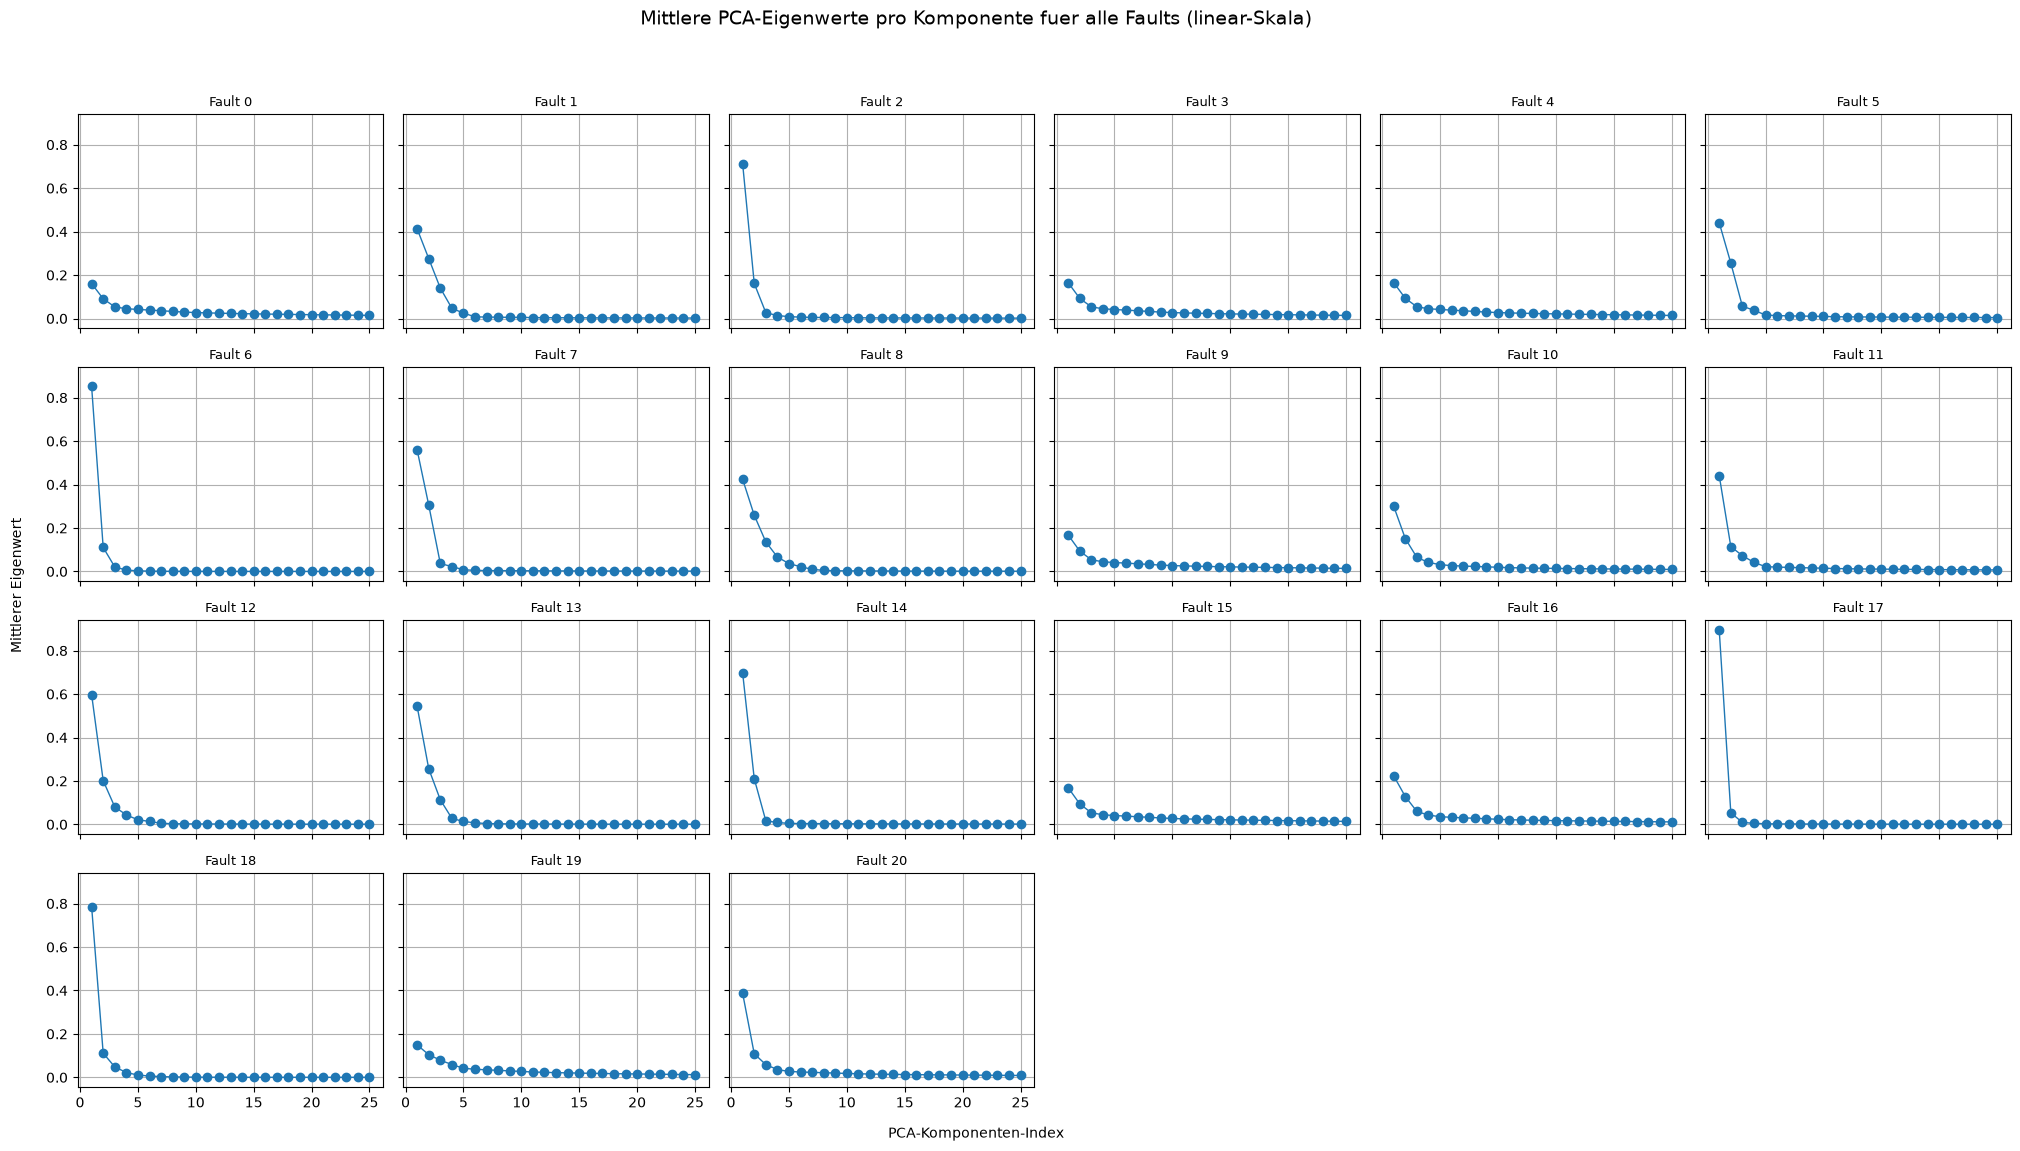

In [8]:
import matplotlib.pyplot as plt
import math

# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der mittlere
# Eigenwertverlauf ueber die ersten k Komponenten.
# ============================================================

# Welche Faults gibt es? Aus dem aggregierten DataFrame ablesen.
all_faults = sorted(agg["faultNumber"].unique())
n_faults   = len(all_faults)

# Nur die Mittelwert-Spalten (lambda_i_mean) fuer den Plot heraussuchen.
# Die _std-Spalten werden in der naechsten Zelle separat visualisiert.
mean_cols = [
    c for c in agg.columns
    if c.startswith("lambda_") and c.endswith("_mean")
]
n_components_total = len(mean_cols)

# Eigenwertspektrum ueber 52 Dimensionen ist visuell unuebersichtlich
# und die hinteren Eigenwerte sind ohnehin nahe null. Wir beschraenken
# uns auf die ersten k Hauptkomponenten.
k_max = 25
n_components = min(k_max, n_components_total)
mean_cols    = mean_cols[:n_components]

print("Anzahl Faults:", n_faults)
print("Anzahl Komponenten pro Fault (geplottet):", n_components)


# ============================================================
# Hilfsfunktion: Transformation der Eigenwerte vor dem Plotten
# ============================================================
def transform_eigenvalues(vals, mode="log"):
    """
    Transformiert einen Vektor von Eigenwerten fuer die Darstellung.

    mode = "linear"   -> keine Transformation. Bei den normierten
                         Varianzanteilen (Summe = 1) gut lesbar fuer die
                         dominanten ersten Komponenten; der Noise-Tail
                         (~1e-6 und kleiner) liegt optisch auf der Nulllinie.
    mode = "log"      -> log10(Eigenwert). Macht die Groessenordnungs-
                         Unterschiede zwischen Komponenten sichtbar.
    mode = "relative" -> Eigenwert / lambda_1. Zeigt nur noch das
                         "Profil" / die Form des Spektrums, unabhaengig
                         vom Absolutniveau einer Fault.
    """
    vals = np.asarray(vals, dtype=float)

    if mode == "linear":
        return vals

    if mode == "log":
        # log10(0) ist -inf -> kleinen Offset einsetzen, um Plot-NaNs zu vermeiden.
        eps = 1e-8
        return np.log10(np.maximum(vals, eps))

    if mode == "relative":
        if vals[0] <= 0:
            # Defensiver Fallback: bei lambda_1 <= 0 (numerisch entartet)
            # waere die Normierung undefiniert.
            return vals
        return vals / vals[0]

    raise ValueError(f"Unbekannter mode: {mode}")


# Darstellungsmodus:
#   "linear"   -> zeigt die dominanten ersten Varianzanteile direkt (aktuelle Wahl)
#   "log"      -> macht zusaetzlich den Noise-Tail sichtbar (Ratios bis ~1e-13,
#                 geclippt bei eps = 1e-8)
#   "relative" -> wenn nur die Form des Spektrums interessiert (alle starten bei 1.0)
plot_mode = "linear"


# ============================================================
# Subplot-Raster aufbauen (z.B. 4 Zeilen x 6 Spalten fuer 21 Faults)
# ============================================================
max_cols = 6
n_cols   = min(max_cols, n_faults)
n_rows   = math.ceil(n_faults / n_cols)

# sharex/sharey=True: alle Subplots teilen sich Achsen -> Faults sind
# auf einen Blick vergleichbar.
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 3.0 * n_rows),
    sharex=True,
    sharey=True,
)

# axes kann je nach n_rows/n_cols ein 2D-Array, 1D-Array oder ein
# einzelnes Achse-Objekt sein. flach machen, damit wir gleichmaessig
# indizieren koennen.
axes = np.array(axes).reshape(-1)

# x-Achse: Komponenten-Indizes 1..n_components
x = range(1, n_components + 1)

# Pro Fault einen Subplot fuellen.
for idx, f in enumerate(all_faults):
    ax  = axes[idx]
    row = agg[agg["faultNumber"] == f]

    # Sollte nicht passieren (Fault stammt ja aus agg), aber defensiv:
    if row.empty:
        ax.set_visible(False)
        continue

    # Die n_components Mittelwerte als 1D-Vektor.
    means  = row[mean_cols].values.flatten()
    y_vals = transform_eigenvalues(means, mode=plot_mode)

    ax.plot(x, y_vals, marker="o", linewidth=1)
    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True)

# Wenn 21 Faults in einem 4x6=24-Raster liegen, bleiben 3 Subplots
# leer -> diese ausblenden.
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# y-Achsen-Beschriftung passt sich an den gewaehlten Modus an, damit
# in keinem Fall Missverstaendnisse entstehen.
if plot_mode == "log":
    y_label = "log10(Mittlerer Eigenwert)"
elif plot_mode == "relative":
    y_label = "Mittlerer Eigenwert / lambda_1"
else:
    y_label = "Mittlerer Eigenwert"

fig.suptitle(
    f"Mittlere PCA-Eigenwerte pro Komponente fuer alle Faults ({plot_mode}-Skala)",
    fontsize=14,
)
# Globale Achsenbeschriftungen ueber alle Subplots (statt pro Subplot).
fig.text(0.5,  0.04, "PCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

# tight_layout passt die Abstaende automatisch an; rect laesst Rand
# fuer suptitle / globale Beschriftungen frei.
plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

# Visualisierung: Standardabweichungs-Spektren je Fehlerklasse #

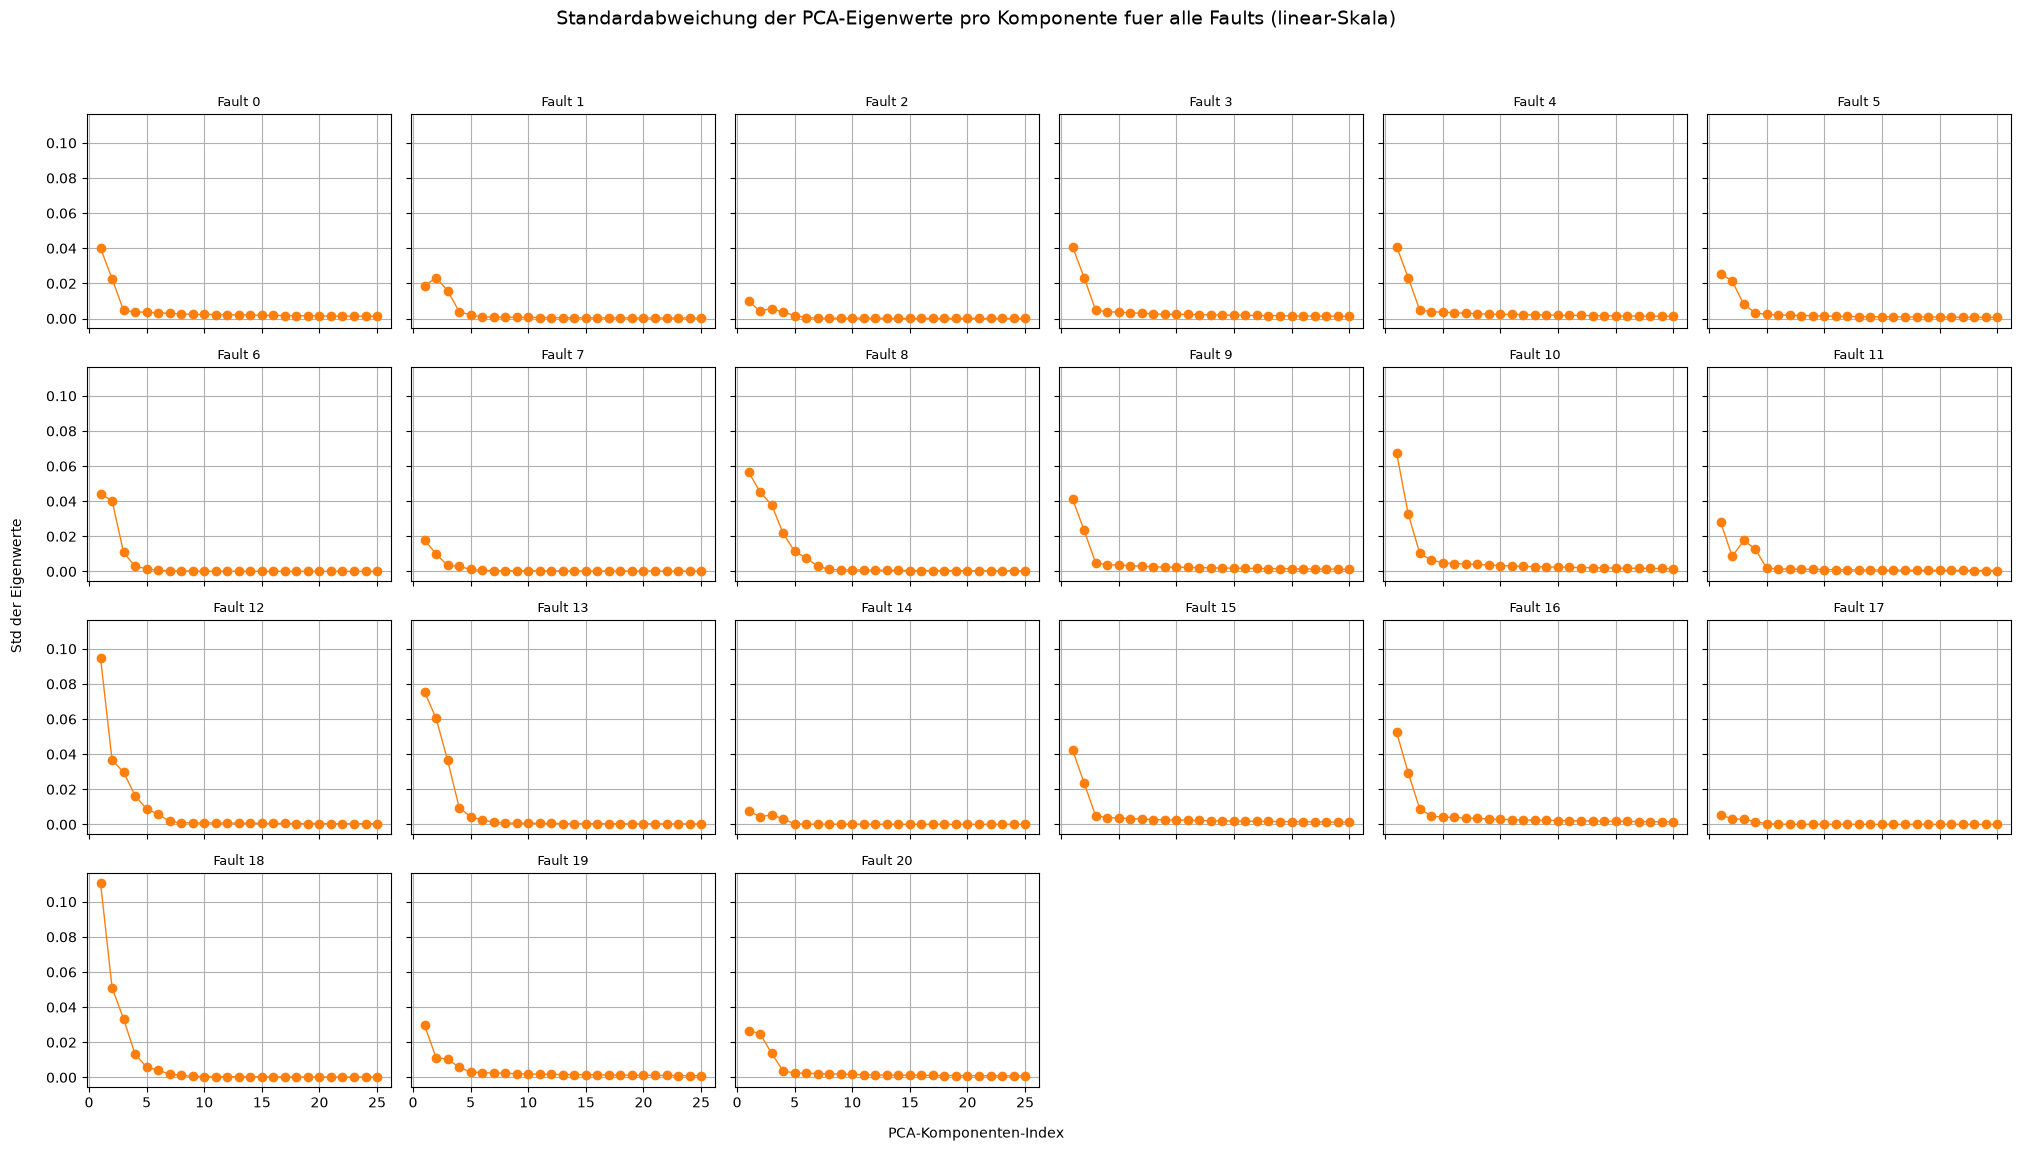

In [9]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der STANDARDABWEICHUNG der Eigenwerte ueber die ersten k Komponenten.
# Struktur identisch zum Mittelwerts-Plot oben; geplottet wird hier
# die *_std-Statistik aus `agg` (in oranger Linienfarbe, damit die
# beiden Visualisierungen visuell unterscheidbar sind).
# ============================================================

# Standardabweichungs-Spalten (lambda_i_std) heraussuchen und auf
# dieselben n_components wie beim Mittelwerts-Plot beschraenken,
# damit die beiden Abbildungen direkt vergleichbar sind.
std_cols = [
    c for c in agg.columns
    if c.startswith("lambda_") and c.endswith("_std")
]
std_cols = std_cols[:n_components]


# ============================================================
# Subplot-Raster aufbauen (gleiche Geometrie wie beim Mittelwerts-Plot)
# ============================================================
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 3.0 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

# Pro Fault einen Subplot fuellen.
for idx, f in enumerate(all_faults):
    ax  = axes[idx]
    row = agg[agg["faultNumber"] == f]

    if row.empty:
        ax.set_visible(False)
        continue

    stds   = row[std_cols].values.flatten()
    y_vals = transform_eigenvalues(stds, mode=plot_mode)

    # color="C1" -> Matplotlib-Standard-Orange, hebt sich vom Mittelwerts-Plot ab.
    ax.plot(x, y_vals, marker="o", linewidth=1, color="C1")
    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True)

# Unbenutzte Achsen ausblenden (z.B. bei 21 Faults in 4x6-Raster).
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# y-Achsen-Beschriftung passt sich an den Modus an.
if plot_mode == "log":
    y_label = "log10(Std der Eigenwerte)"
elif plot_mode == "relative":
    y_label = "Std-Verhaeltnis (Std_i / Std_1)"
else:
    y_label = "Std der Eigenwerte"

fig.suptitle(
    f"Standardabweichung der PCA-Eigenwerte pro Komponente fuer alle Faults ({plot_mode}-Skala)",
    fontsize=14,
)
fig.text(0.5,  0.04, "PCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

# Visualisierung: relative Streuung (Variationskoeffizient) je Fehlerklasse #

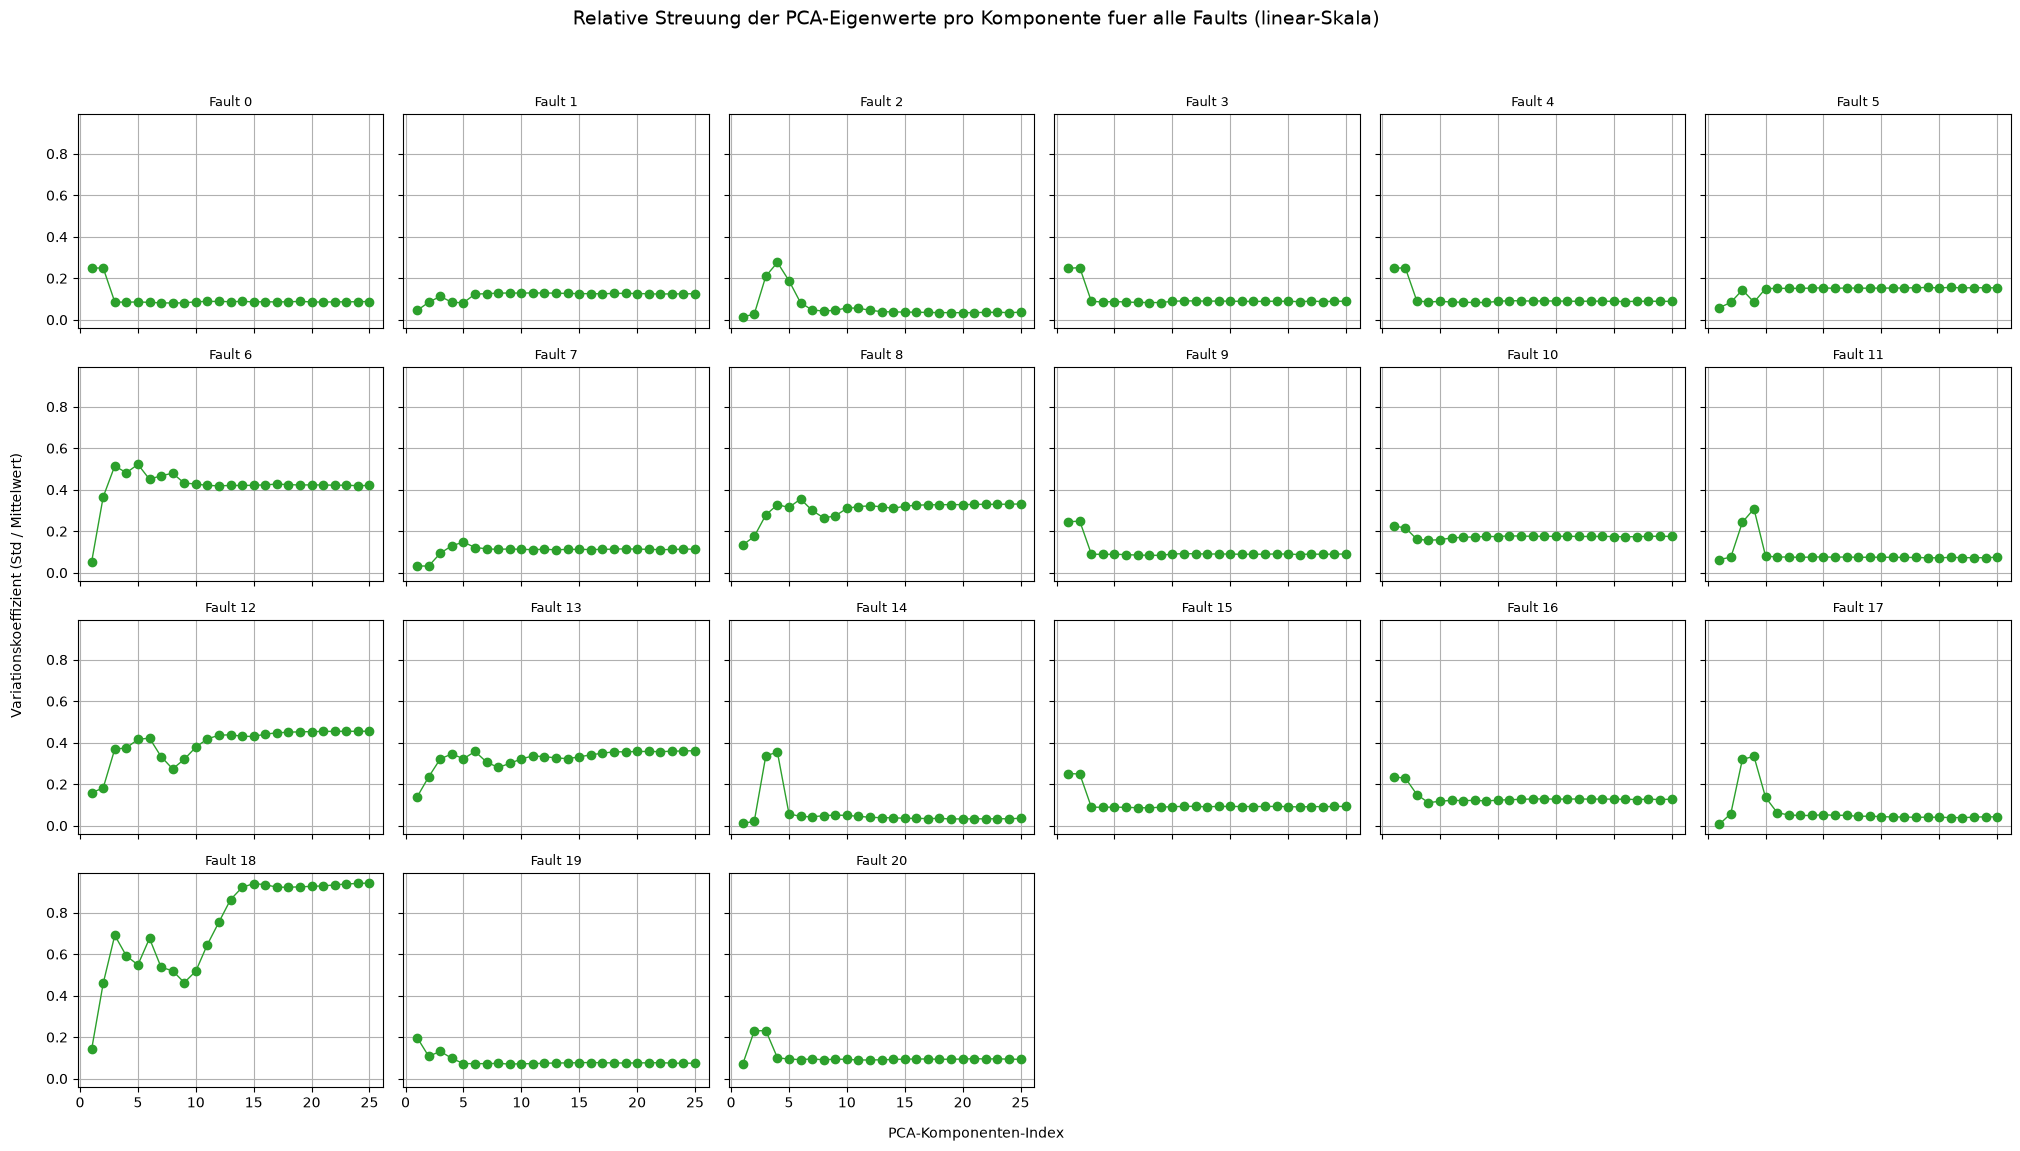

In [10]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der RELATIVEN STREUUNG (Variationskoeffizient) der Eigenwerte
# ueber die ersten k Komponenten.
#
#     CV_i = lambda_i_std / lambda_i_mean
#
# Interpretation:
#   - Klein (z.B. < 0.1): Eigenwert ist ueber alle 500 Runs sehr stabil.
#   - Gross (z.B. > 0.5): Eigenwert schwankt von Run zu Run stark
#                          (= grosse Streuung der Fault-Auspraegung).
#
# Struktur identisch zu den vorigen beiden Plots; geplottet wird in
# gruener Linienfarbe, um die drei Visualisierungen visuell sauber
# voneinander abzugrenzen (blau = Mittelwert, orange = Std,
# gruen = CV).
# ============================================================

# Eigener Skalen-Modus fuer diesen Plot - bewusst LINEAR, weil CVs
# dimensionslose Verhaeltnisse sind und im Bereich 0..1 (oft 0..0.3)
# liegen. Eine lineare y-Achse ist hier intuitiver lesbar als log10.
# Die anderen beiden Plots (Mittelwert, Std) bleiben unveraendert auf
# der globalen plot_mode-Einstellung (typischerweise "log").
plot_mode_cv = "linear"

# Subplot-Raster aufbauen (gleiche Geometrie wie bei Mittelwert/Std).
# sharey=True: die 21 CV-Subplots teilen sich EINE y-Skala, damit die
# Faults untereinander vergleichbar sind. Von den Mittelwert-/Std-Plots
# ist diese Figure ohnehin unabhaengig (eigene Achsen, eigene Skala).
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 3.0 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

# Pro Fault einen Subplot fuellen.
for idx, f in enumerate(all_faults):
    ax  = axes[idx]
    row = agg[agg["faultNumber"] == f]

    if row.empty:
        ax.set_visible(False)
        continue

    # Mittelwerte und Std fuer die ersten n_components Komponenten
    # in der gleichen Reihenfolge auslesen (lambda_1 .. lambda_k).
    means = row[mean_cols].values.flatten()
    stds  = row[std_cols].values.flatten()

    # Variationskoeffizient elementweise: CV_i = std_i / mean_i.
    # Bei den PCA-Eigenwerten sind die Mittelwerte strikt positiv
    # (Eigenwerte einer Kovarianzmatrix >= 0); eine Division ist
    # daher unkritisch. np.errstate-Block schuetzt nur vor seltenen
    # numerischen Entartungen (mean ~ 0 bei lambda_51, lambda_52).
    with np.errstate(divide="ignore", invalid="ignore"):
        cv = np.where(means > 0, stds / means, np.nan)

    # Lokaler plot_mode_cv (typischerweise "linear") - unabhaengig
    # vom globalen plot_mode der vorigen Plots.
    y_vals = transform_eigenvalues(cv, mode=plot_mode_cv)

    # color="C2" -> Matplotlib-Standard-Gruen.
    ax.plot(x, y_vals, marker="o", linewidth=1, color="C2")
    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True)

# Unbenutzte Achsen ausblenden (z.B. bei 21 Faults in 4x6-Raster).
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# y-Achsen-Beschriftung passt sich an den lokalen Modus an.
if plot_mode_cv == "log":
    y_label = "log10(CV) = log10(Std / Mittelwert)"
elif plot_mode_cv == "relative":
    y_label = "CV_i / CV_1"
else:
    y_label = "Variationskoeffizient (Std / Mittelwert)"

fig.suptitle(
    f"Relative Streuung der PCA-Eigenwerte pro Komponente fuer alle Faults ({plot_mode_cv}-Skala)",
    fontsize=14,
)
fig.text(0.5,  0.04, "PCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

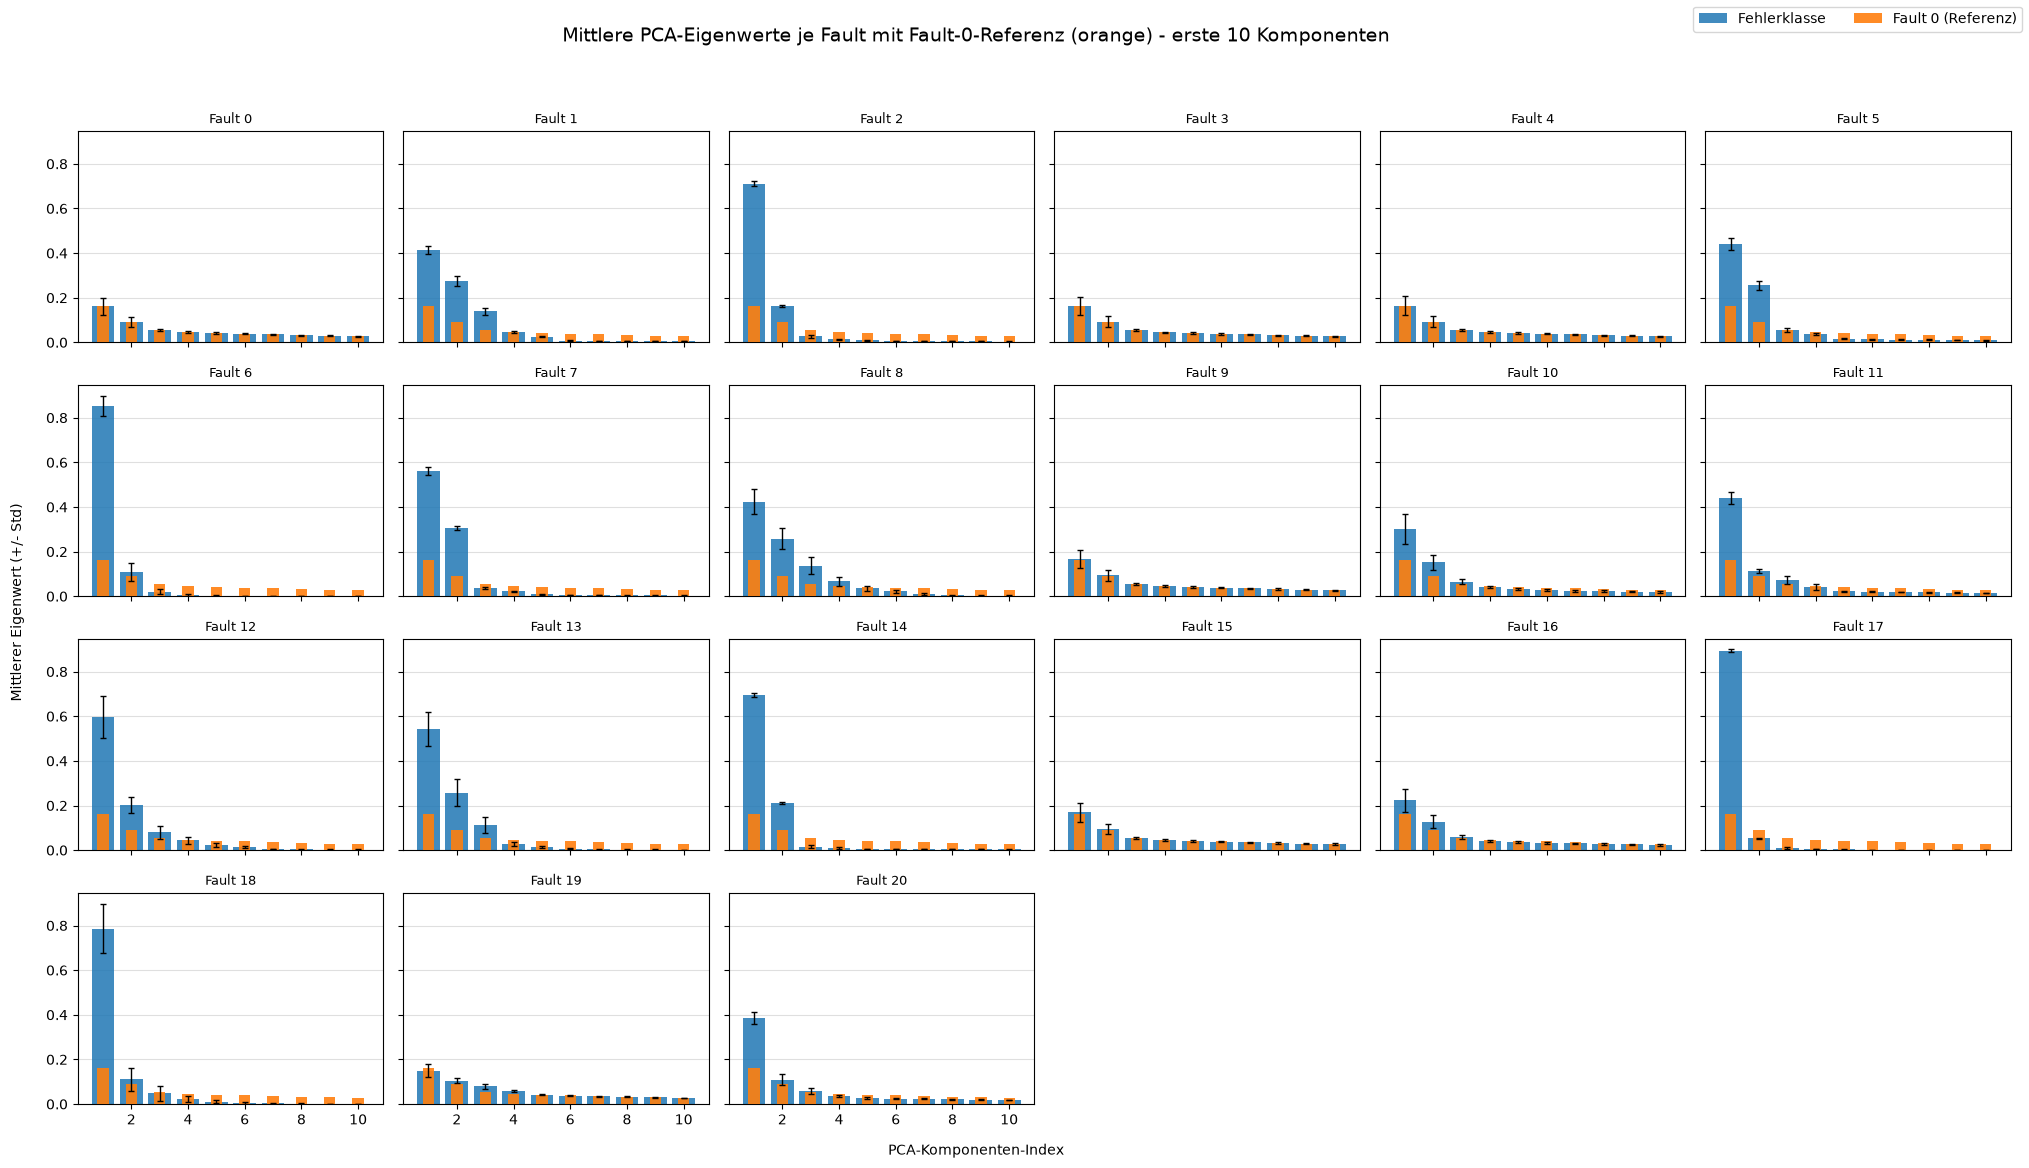

In [11]:
# ============================================================
# Bar-Plot: erste k Eigenwerte je Fault MIT Fault-0-Overlay (Referenz)
# ============================================================
# Pro Fehlerklasse ein Subplot:
#   - breite blaue Balken  = mittlerer PCA-Eigenwert der Klasse,
#   - schmale orange Balken= Eigenwert-Mittelwert von Fault 0 (Normal-
#                            betrieb), zentriert oben drauf als Referenz,
#   - schwarze Fehlerbalken= +/- Std ueber die Runs der Klasse, werden
#                            ZULETZT gezeichnet (hoechster zorder), damit
#                            sie nicht vom orange Balken verdeckt werden.
# So ist je Fault direkt ablesbar, welche der ersten k Komponenten
# gegenueber dem fehlerfreien Betrieb abweichen.
#
# Lesehilfe: Faults, deren orange Referenz fast deckungsgleich mit den
# blauen Balken ist, sind anhand des Eigenwertspektrums kaum vom Normal-
# betrieb zu unterscheiden (z.B. die bekannt schwer detektierbaren
# TEP-Faults 3/4/9/15). Der Subplot "Fault 0" zeigt die Referenz auf
# sich selbst (perfekte Ueberlappung) - dient als Sanity-Check.

k_bar = 10
mean_cols_bar = [f"lambda_{i}_mean" for i in range(1, k_bar + 1)]
std_cols_bar  = [f"lambda_{i}_std"  for i in range(1, k_bar + 1)]

faults   = sorted(agg["faultNumber"].unique())
n_faults = len(faults)
ncols    = 6
nrows    = int(np.ceil(n_faults / ncols))

# Referenz-Spektrum: Mittelwerte von Fault 0 (Normalbetrieb).
ref_means = agg[agg["faultNumber"] == 0].iloc[0][mean_cols_bar].values.astype(float)

x = np.arange(1, k_bar + 1)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.5 * ncols, 3.0 * nrows),
    sharex=True, sharey=True,
)
axes = np.array(axes).reshape(-1)

for i, f in enumerate(faults):
    ax  = axes[i]
    row = agg[agg["faultNumber"] == f].iloc[0]
    means = row[mean_cols_bar].values.astype(float)
    stds  = row[std_cols_bar].values.astype(float)

    # Klasse f: breite Balken (blau), OHNE yerr (Fehlerbalken kommen unten).
    ax.bar(x, means, width=0.8,
           color="C0", alpha=0.85,
           label="Fehlerklasse", zorder=2)
    # Fault 0 (Referenz): schmale orange Balken oben drauf.
    ax.bar(x, ref_means, width=0.4,
           color="tab:orange", alpha=0.9,
           label="Fault 0 (Referenz)", zorder=3)
    # Std-Fehlerbalken ZULETZT -> liegen sichtbar ueber dem orange Balken.
    ax.errorbar(x, means, yerr=stds, fmt="none",
                ecolor="black", capsize=2, elinewidth=1, zorder=4)

    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True, axis="y", alpha=0.4)

# Unbenutzte Achsen ausblenden (21 Faults in 4x6-Raster).
for j in range(n_faults, len(axes)):
    axes[j].set_visible(False)

# Gemeinsame Legende (generische Labels aus dem ersten Subplot).
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=10)

fig.suptitle(
    f"Mittlere PCA-Eigenwerte je Fault mit Fault-0-Referenz (orange) "
    f"- erste {k_bar} Komponenten",
    fontsize=14,
)
fig.text(0.5,  0.04, "PCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  "Mittlerer Eigenwert (+/- Std)", va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

# Export: Train-Eigenwerte (für LazyClassifier)

Stellt die berechneten **Trainings**-Eigenwerte als CSV bereit. Die
**Test**-Eigenwerte werden bewusst NICHT hier berechnet, sondern direkt im
`LazyClassifier_PCA_DyCA.ipynb` — dieses Notebook bleibt auf die
Trainings-Analyse beschränkt.

In [12]:
# ============================================================
# Export: PCA-Eigenwerte (Training) als CSV
# ============================================================
eigenvalues_per_run.to_csv("pca_eigenvalues_train.csv", index=False)
print("PCA-Train gespeichert:", eigenvalues_per_run.shape,
      "-> pca_eigenvalues_train.csv")

PCA-Train gespeichert: (10500, 54) -> pca_eigenvalues_train.csv
